# TOUMÖLA — Fine-tuning EfficientNetB3
## Medicinal Plant Classification + Automatic Data Entry

**Objective**: Train a model that, given a photo of a plant, automatically returns:
- Scientific name
- Botanical family  
- Description
- Medicinal use
- Part used

**Model**: EfficientNetB3 (pre-trained on ImageNet  fine-tuned on plants)  
**Kaggle GPU**: T4 or P100 (enabled in Settings  Accelerator)

---
### Before you begin
1. Enable the GPU: **Settings  Accelerator  GPU T4 x2**
2. Upload the file `toumola_dataset_final.csv` to the Kaggle inputs
3. Upload the folder `images/` (zipped) to the Kaggle inputs


## Step 1 — Installing the libraries

In [1]:
import subprocess
subprocess.run(["pip", "install", "timm", "albumentations", "torchmetrics", "-q"])
print(" Librairies installed")


 Librairies installed


## Step 2 — Imports

In [2]:
import os, zipfile, shutil, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import torchmetrics

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Step 3 — Configuration

In [3]:
# 
# CONFIGURATION — Modify as needed
# 

# Paths (Kaggle: /kaggle/input/your-dataset/)
# Automatically finds the correct path
def find_file(filename, search_dirs=["/kaggle/input", "/kaggle/working", "."]):
    for d in search_dirs:
        for root, dirs, files in os.walk(d):
            for f in files:
                if f == filename:
                    return os.path.join(root, f)
    return None

def find_images_dir(search_dirs=["/kaggle/input", "/kaggle/working", "."]):
    for d in search_dirs:
        for root, dirs, files in os.walk(d):
            for dir_name in dirs:
                if dir_name == "images":
                    full_path = os.path.join(root, dir_name)
                    # Check if it contains images
                    imgs = [f for f in os.listdir(full_path) 
                            if f.lower().endswith(('.jpg','.jpeg','.png'))]
                    if len(imgs) > 5:
                        return full_path
    return None

CSV_PATH    = find_file("toumola_dataset_final.csv") or "toumola_dataset_final.csv"
IMAGES_DIR  = find_images_dir() or "images"
OUTPUT_DIR  = "/kaggle/working/toumola_model"
MODEL_PATH  = f"{OUTPUT_DIR}/efficientnet_toumola.pth"
LABELS_PATH = f"{OUTPUT_DIR}/labels.json"
ZIP_PATH    = find_file("images.zip")

print(f"CSV      : {CSV_PATH}")
print(f"Images   : {IMAGES_DIR}")
print(f"Output   : {OUTPUT_DIR}")
print(f"ZIP      : {ZIP_PATH}")

# Hyperparameters
IMG_SIZE    = 224      # EfficientNetB3 input size
BATCH_SIZE  = 32       # reduce to 16 if memory is insufficient
EPOCHS      = 30       # 30 epochs = good speed/accuracy trade-off
LR          = 1e-4     # initial learning rate
LR_MIN      = 1e-6     # minimum learning rate (scheduler)
UNFREEZE_EPOCH = 10    # epoch at which the backbone is unfrozen
PATIENCE    = 7        # early stopping patience
VAL_SPLIT   = 0.15     # 15% validation
TEST_SPLIT  = 0.10     # 10% test


os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration OK")


CSV      : /kaggle/input/datasets/ansoumaneconde/dataset1/output/toumola_dataset_final.csv
Images   : /kaggle/input/datasets/ansoumaneconde/dataset1/output/images
Output   : /kaggle/working/toumola_model
ZIP      : None
Configuration OK


## Step 4 — Loading and preparing the data

In [4]:
# Unzip the images if necessary
if ZIP_PATH and not os.path.exists(IMAGES_DIR):
    print(f"Unzipping {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/kaggle/working/")
    IMAGES_DIR = find_images_dir(["/kaggle/working"]) or "images"
    print(f"Images unzipped to {IMAGES_DIR}")

# Load the CSV file
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"Dataset loaded: {len(df)} rows")
print(f"   Columns: {list(df.columns)}")

# Cleaning: remove rows with missing Image or scientific name
df = df.dropna(subset=["Image", "Nom_scientifique"])
df = df[df["Image"].str.strip() != ""]
df["Nom_scientifique"] = df["Nom_scientifique"].str.strip()

# Check that each image file exists on disk
def image_exists(img_path):
    # Try several possible paths for the image file
    candidates = [
        img_path,
        os.path.join(IMAGES_DIR, os.path.basename(img_path)),
        os.path.join("/kaggle/working", img_path),
        os.path.join("/kaggle/input", img_path),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

print("Checking images...")
df["image_full_path"] = df["Image"].apply(image_exists)
df_valid = df[df["image_full_path"].notna()].copy()
df_missing = df[df["image_full_path"].isna()]

print(f"   Images found   : {len(df_valid)}")
print(f"   Missing images : {len(df_missing)}")

if len(df_valid) == 0:
    print("No images found!")
    print("   Make sure your ‘images/’ folder has been uploaded to Kaggle")
    print(f"   Current IMAGES_DIR: {IMAGES_DIR}")
else:
    df = df_valid.copy()
    print(f"{len(df)} valid images for training")

# Statistics per species
species_counts = df["Nom_scientifique"].value_counts()
print("Statistics:")
print(f"   Number of species: {len(species_counts)}")
print(f"   Images per species (min/max/avg): {species_counts.min()} / {species_counts.max()} / {species_counts.mean():.0f}")
print("   Top 10 species:")
print(species_counts.head(10).to_string())


Dataset loaded: 7780 rows
   Columns: ['Image', 'Nom_scientifique', 'Famille', 'Description', 'Usage_medicinal', 'Partie_utilisee', 'Medicinal']
Checking images...
   Images found   : 7780
   Missing images : 0
7780 valid images for training
Statistics:
   Number of species: 55
   Images per species (min/max/avg): 34 / 258 / 141
   Top 10 species:
Nom_scientifique
Jasminum officinale        258
Mentha spicata             250
Basella alba               249
Lythraceae                 225
Phragmanthera leonensis    211
Mangifera indica           208
Phragmanthera capitata     208
Nerium oleander            208
Pongamia pinnata           207
Azadirachta                206


##  Step 5 — Dataset visualization

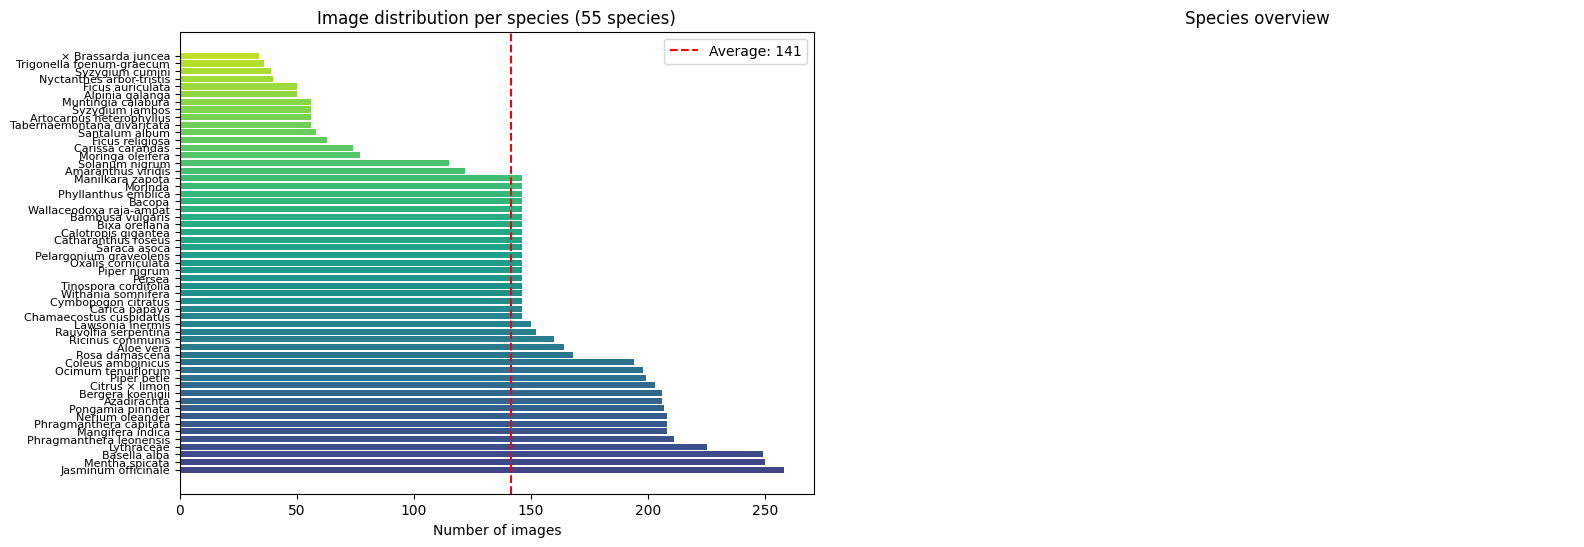

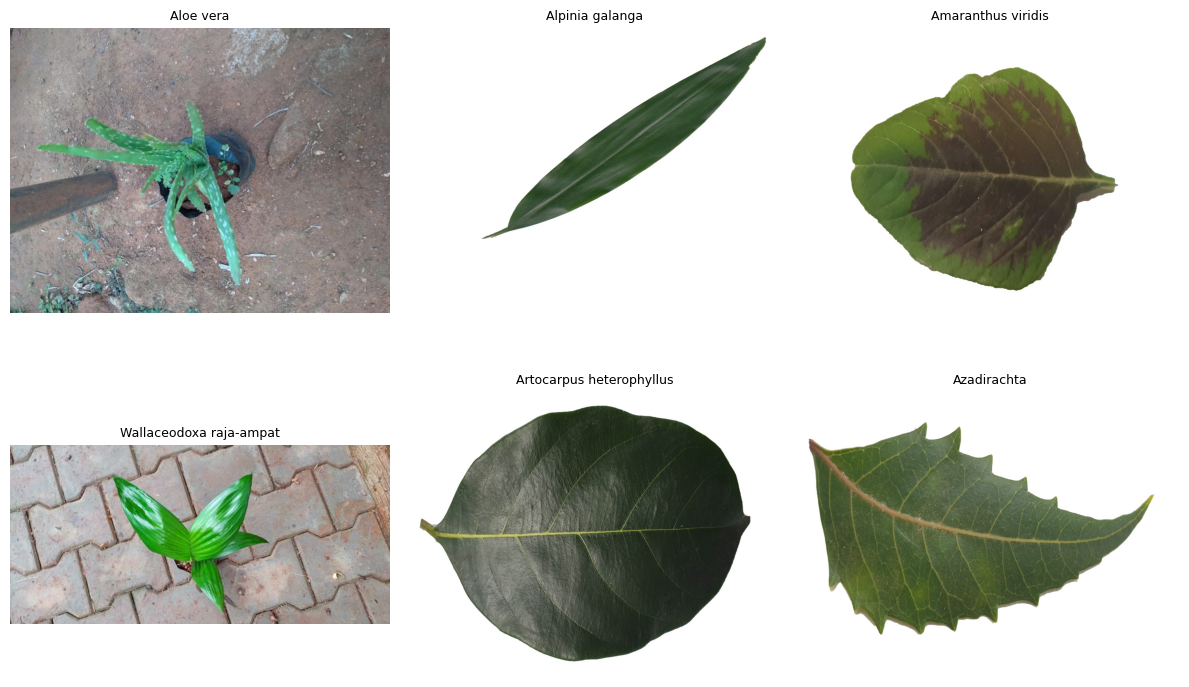

Visualization saved


In [5]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Number of images per species
species_counts = df["Nom_scientifique"].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(species_counts)))
axes[0].barh(range(len(species_counts)), species_counts.values, color=colors)
axes[0].set_yticks(range(len(species_counts)))
axes[0].set_yticklabels([s[:30] for s in species_counts.index], fontsize=8)
axes[0].set_xlabel("Number of images")
axes[0].set_title(f"Image distribution per species ({len(species_counts)} species)")
axes[0].axvline(x=species_counts.mean(), color='red', linestyle='--', 
                label=f'Average: {species_counts.mean():.0f}')
axes[0].legend()

# Chart 2: Sample images
sample_species = df["Nom_scientifique"].unique()[:6]
axes[1].axis('off')
axes[1].set_title("Species overview")

fig2, ax2 = plt.subplots(2, 3, figsize=(12, 8))
for idx, species in enumerate(sample_species[:6]):
    row, col = idx // 3, idx % 3
    sample_img_path = df[df["Nom_scientifique"] == species]["image_full_path"].iloc[0]
    try:
        img = Image.open(sample_img_path).convert("RGB")
        ax2[row, col].imshow(img)
        ax2[row, col].set_title(species[:25], fontsize=9)
        ax2[row, col].axis('off')
    except Exception as e:
        ax2[row, col].text(0.5, 0.5, f"Error\n{species[:20]}", 
                          ha='center', va='center', transform=ax2[row, col].transAxes)
        ax2[row, col].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_overview.png", dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved")


##  Step 6 — Label encoding and train/val/test split

In [6]:
# Encode species names as integer indices
species_list = sorted(df["Nom_scientifique"].unique())
species_to_idx = {s: i for i, s in enumerate(species_list)}
idx_to_species = {i: s for s, i in species_to_idx.items()}
NUM_CLASSES = len(species_list)

df["label"] = df["Nom_scientifique"].map(species_to_idx)

print(f"{NUM_CLASSES} classes encoded")
print(f"   Example: 'Aloe vera' -> {species_to_idx.get('Aloe vera', 'N/A')}")

# Save the label mapping to disk
labels_data = {
    "species_to_idx": species_to_idx,
    "idx_to_species": {str(k): v for k, v in idx_to_species.items()},
    "num_classes": NUM_CLASSES
}
with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(labels_data, f, ensure_ascii=False, indent=2)
print(f"Labels saved: {LABELS_PATH}")

# Stratified train / val / test split
# Keep only species with at least 3 images (required for stratified split)
min_samples = 3
valid_species = df["Nom_scientifique"].value_counts()
valid_species = valid_species[valid_species >= min_samples].index
df_split = df[df["Nom_scientifique"].isin(valid_species)].copy()
df_rare  = df[~df["Nom_scientifique"].isin(valid_species)].copy()

print(f"   Species with >={min_samples} images: {len(valid_species)}")
print(f"   Rare species (<{min_samples} images): {df['Nom_scientifique'].nunique() - len(valid_species)}")

# Perform the stratified split
df_train, df_temp = train_test_split(
    df_split, test_size=(VAL_SPLIT + TEST_SPLIT), 
    stratify=df_split["label"], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    stratify=df_temp["label"], random_state=42
)

# Add rare-species images to the training set
df_train = pd.concat([df_train, df_rare], ignore_index=True)

print("Dataset split:")
print(f"   Train      : {len(df_train)} images ({len(df_train)/len(df)*100:.1f}%)")
print(f"   Validation : {len(df_val)} images ({len(df_val)/len(df)*100:.1f}%)")
print(f"   Test       : {len(df_test)} images ({len(df_test)/len(df)*100:.1f}%)")


55 classes encoded
   Example: 'Aloe vera' -> 0
Labels saved: /kaggle/working/toumola_model/labels.json
   Species with >=3 images: 55
   Rare species (<3 images): 0
Dataset split:
   Train      : 5835 images (75.0%)
   Validation : 1167 images (15.0%)
   Test       : 778 images (10.0%)


##  Step 7 — PyTorch Dataset + Data Augmentation

Supplement added based on recommendations

In [7]:
class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_full_path"]
        label    = int(row["label"])
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(200, 200, 200))
        if self.transform:
            img = self.transform(img)
        return img, label, img_path


# Transforms -- strong augmentation for the training set
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# DataLoaders
train_dataset = PlantDataset(df_train, train_transform)
val_dataset   = PlantDataset(df_val,   val_transform)
test_dataset  = PlantDataset(df_test,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created")
print(f"   Train batches      : {len(train_loader)}")
print(f"   Validation batches : {len(val_loader)}")
print(f"   Test batches       : {len(test_loader)}")


DataLoaders created
   Train batches      : 183
   Validation batches : 37
   Test batches       : 25


##  Step 8 — EfficientNetB3 Model

In [19]:
# Load EfficientNetB3 pre-trained on ImageNet
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=NUM_CLASSES
)

# Phase 1: freeze the backbone, train only the classifier head
for name, param in model.named_parameters():
    if "classifier" not in name and "head" not in name:
        param.requires_grad = False

# Count trainable parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("EfficientNetB3 loaded")
print(f"   Total parameters      : {total_params:,}")
print(f"   Trainable parameters  : {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"   Number of classes     : {NUM_CLASSES}")
print(f"   Phase 1 (epochs 1-{UNFREEZE_EPOCH}): backbone frozen, training head only")
print(f"   Phase 2 (epochs {UNFREEZE_EPOCH}+): backbone unfrozen, full fine-tuning")

model = model.to(device)

# Loss curve function, optimizer and learning rate scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

print(f"Optimizer : AdamW (lr={LR})")
print("Scheduler : CosineAnnealingLR")
print("Loss      : CrossEntropy + label smoothing 0.1")


EfficientNetB3 loaded
   Total parameters      : 10,780,767
   Trainable parameters  : 674,359 (6.3%)
   Number of classes     : 55
   Phase 1 (epochs 1-10): backbone frozen, training head only
   Phase 2 (epochs 10+): backbone unfrozen, full fine-tuning
Optimizer : AdamW (lr=0.0001)
Scheduler : CosineAnnealingLR
Loss      : CrossEntropy + label smoothing 0.1


##  Step 9 — Training

In [20]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


# Main training loop
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
patience_counter = 0

print(f"Starting training -- {EPOCHS} epochs\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8}")
print("" * 65)

for epoch in range(1, EPOCHS + 1):

    # Phase 2: unfreeze the backbone starting at UNFREEZE_EPOCH
    if epoch == UNFREEZE_EPOCH:
        print(f"\nEpoch {epoch}: Backbone unfrozen -- full fine-tuning")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR / 10, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - UNFREEZE_EPOCH, eta_min=LR_MIN
        )
        print("")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>8.2%} | {current_lr:>8.2e}")

    # Save the best model so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "num_classes": NUM_CLASSES,
        }, MODEL_PATH)
        print(f"         Best model saved (val_acc={val_acc:.2%})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping à l'epoch {epoch} (patience={PATIENCE})")
            break

print(f"\nTraining complete. Best val_acc: {best_val_acc:.2%}")


Starting training -- 30 epochs

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR

     1 |     3.7555 |   11.77% |   3.2031 |   26.39% | 9.97e-05
         Best model saved (val_acc=26.39%)
     2 |     2.8371 |   36.86% |   2.5421 |   49.79% | 9.89e-05
         Best model saved (val_acc=49.79%)
     3 |     2.2934 |   56.47% |   2.1008 |   62.64% | 9.76e-05
         Best model saved (val_acc=62.64%)
     4 |     1.9763 |   65.76% |   1.9008 |   68.29% | 9.57e-05
         Best model saved (val_acc=68.29%)
     5 |     1.7710 |   72.66% |   1.7698 |   72.07% | 9.34e-05
         Best model saved (val_acc=72.07%)
     6 |     1.6537 |   75.99% |   1.6478 |   75.84% | 9.05e-05
         Best model saved (val_acc=75.84%)
     7 |     1.5570 |   78.25% |   2.2626 |   67.44% | 8.73e-05
     8 |     1.4792 |   81.13% |   1.5128 |   81.66% | 8.36e-05
         Best model saved (val_acc=81.66%)
     9 |     1.4216 |   82.43% |   1.4888 |   81.75% | 7.96e-05
         Best model saved

##  Step 10 — Training Curves

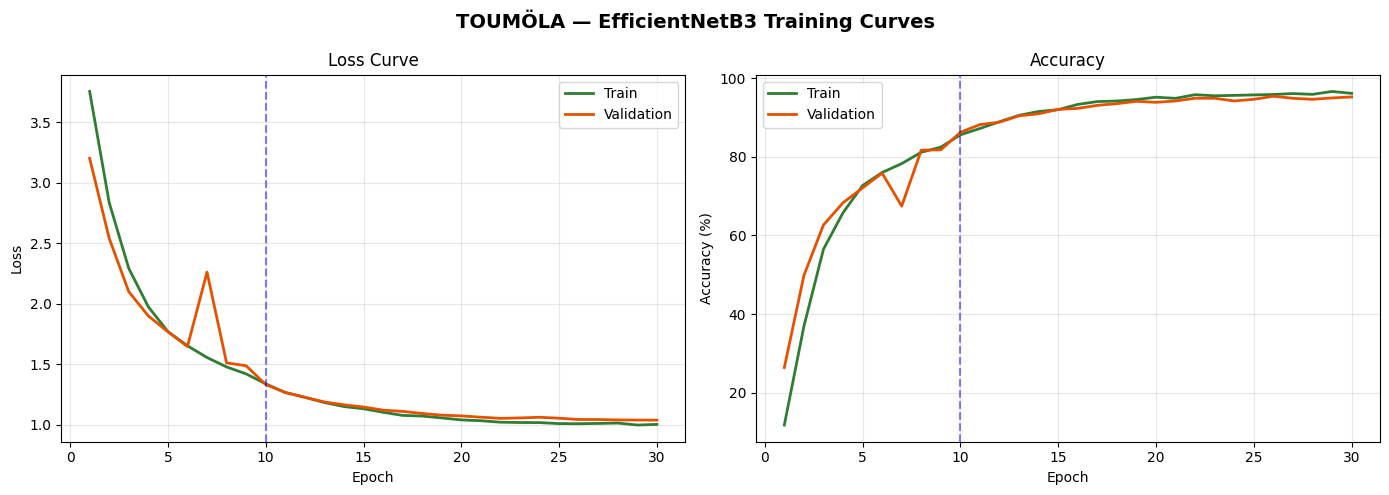

Training curves saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss curve
axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#2E7D32", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Validation", color="#E65100", linewidth=2)
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=UNFREEZE_EPOCH, color='blue', linestyle='--', alpha=0.5, label='Backbone unfrozen')

# Accuracy curve
axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train",      color="#2E7D32", linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Validation", color="#E65100", linewidth=2)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=UNFREEZE_EPOCH, color='blue', linestyle='--', alpha=0.5, label='Backbone unfrozen')

plt.suptitle("TOUMÖLA — EfficientNetB3 Training Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=100, bbox_inches='tight')
plt.show()
print("Training curves saved")


##  Step 11 — Evaluation on the test set

In [22]:
# Load the best saved model
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Best model loaded (epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.2%})")

# Run predictions on the test set
all_preds, all_labels, all_paths = [], [], []
with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Global metrics
test_acc = (all_preds == all_labels).mean()
print("Results on the test set:")
print(f"   Global accuracy: {test_acc:.2%}")

# Detailed per-class classification report
target_names = [idx_to_species[i] for i in range(NUM_CLASSES) 
                if i in np.unique(all_labels)]
label_indices = [i for i in range(NUM_CLASSES) if i in np.unique(all_labels)]

report = classification_report(
    all_labels, all_preds,
    labels=label_indices,
    target_names=target_names,
    zero_division=0
)
print(f"\n{report}")

# Save the report to disk
with open(f"{OUTPUT_DIR}/classification_report.txt", "w", encoding="utf-8") as f:
    f.write("TOUMOLA -- Evaluation report\n")
    f.write(f"Accuracy: {test_acc:.2%}\n\n")
    f.write(report)
print("Report saved")


Best model loaded (epoch 26, val_acc=95.37%)
Results on the test set:
   Global accuracy: 94.47%

                            precision    recall  f1-score   support

                 Aloe vera       1.00      0.94      0.97        16
           Alpinia galanga       0.71      1.00      0.83         5
        Amaranthus viridis       0.92      1.00      0.96        12
  Artocarpus heterophyllus       1.00      1.00      1.00         6
               Azadirachta       0.95      1.00      0.98        21
                    Bacopa       0.83      1.00      0.91        15
          Bambusa vulgaris       1.00      1.00      1.00        14
              Basella alba       0.89      1.00      0.94        25
          Bergera koenigii       0.90      0.90      0.90        20
             Bixa orellana       0.94      1.00      0.97        15
       Calotropis gigantea       1.00      0.93      0.97        15
             Carica papaya       1.00      1.00      1.00        14
          Carissa

##  Step 12 — Confusion Matrix

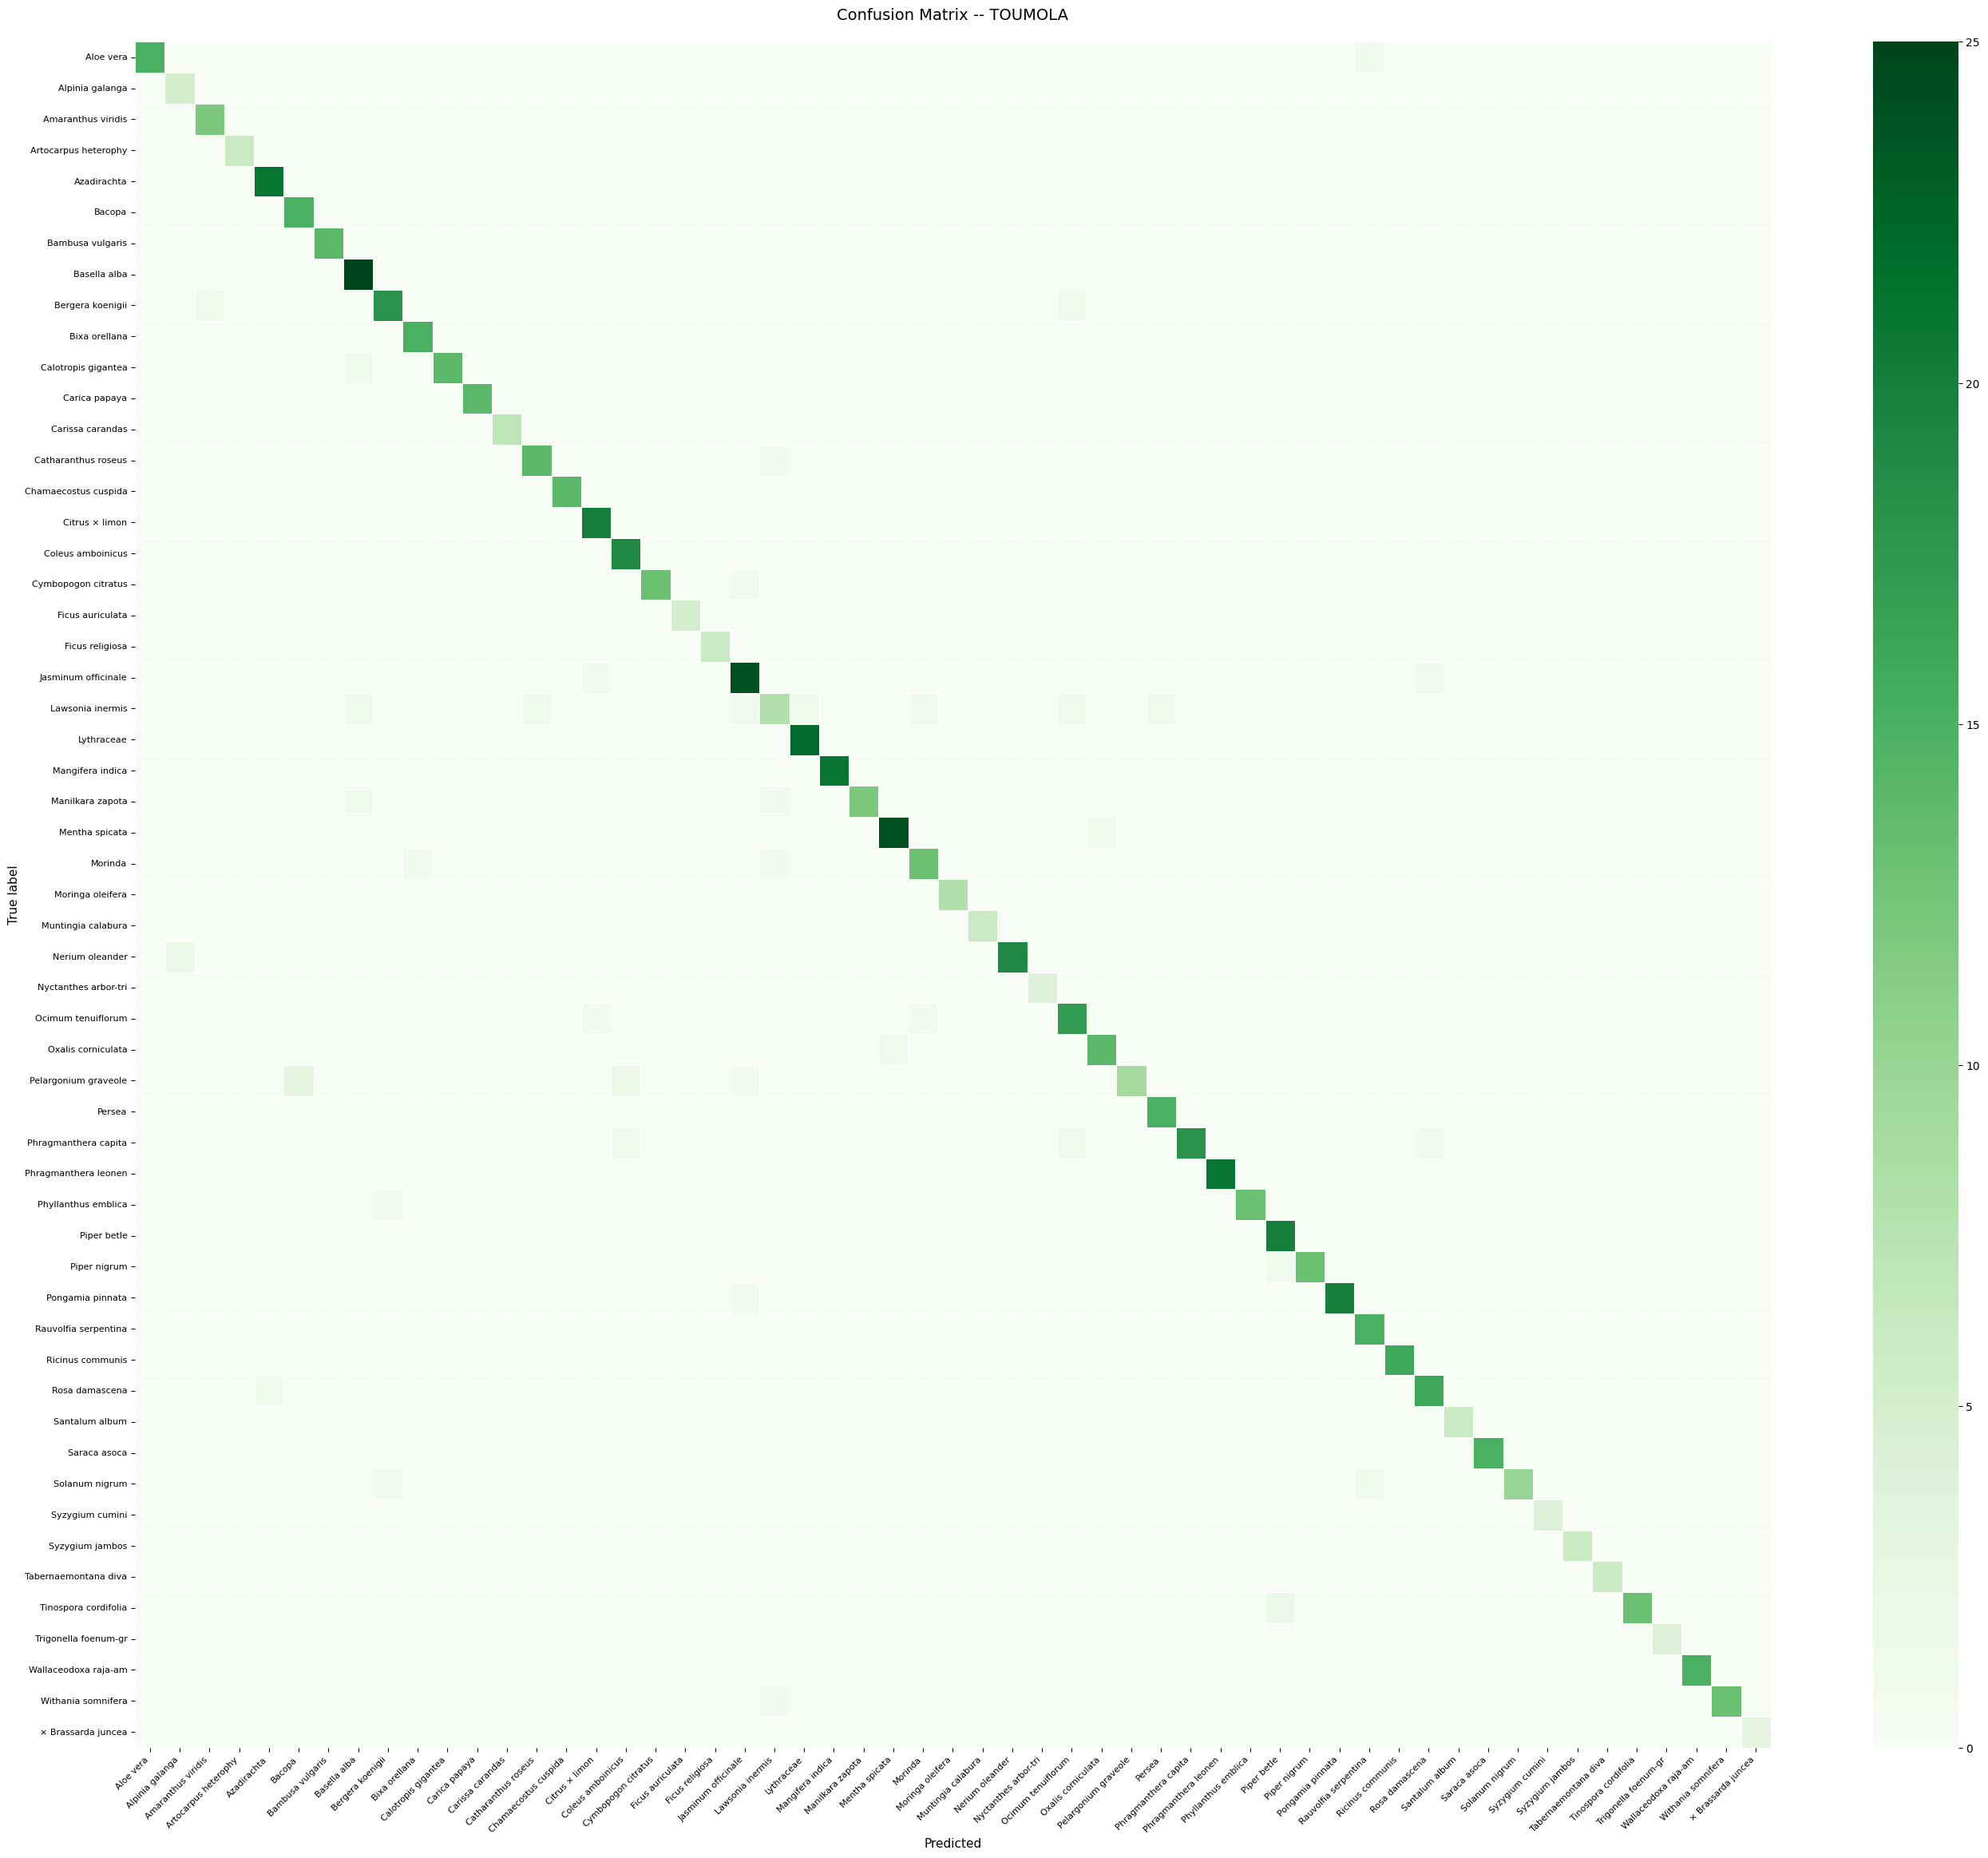

Confusion matrix saved


In [23]:
# Confusion matrix
unique_labels = sorted(np.unique(all_labels))
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
cm_names = [idx_to_species[i][:20] for i in unique_labels]

fig_size = max(12, len(unique_labels) * 0.5)
plt.figure(figsize=(fig_size, fig_size * 0.85))
sns.heatmap(
    cm, annot=len(unique_labels) <= 30,
    fmt='d', cmap='Greens',
    xticklabels=cm_names, yticklabels=cm_names,
    linewidths=0.5
)
plt.title("Confusion Matrix -- TOUMOLA", fontsize=14, pad=20)
plt.ylabel("True label", fontsize=11)
plt.xlabel("Predicted", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")


##  Step 13 — Prediction function + Complete plant record

In [24]:
# Load the CSV to retrieve the complete plant record
df_info = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df_info["Nom_scientifique"] = df_info["Nom_scientifique"].str.strip()

# Build an index: scientific name -> plant info dict
plant_info = {}
for _, row in df_info.iterrows():
    nom = row["Nom_scientifique"]
    if nom not in plant_info:
        plant_info[nom] = {
            "Famille":         str(row.get("Famille", "")         or ""),
            "Description":     str(row.get("Description", "")     or ""),
            "Usage_medicinal": str(row.get("Usage_medicinal", "") or ""),
            "Partie_utilisee": str(row.get("Partie_utilisee", "") or ""),
            "Medicinal":       str(row.get("Medicinal", "Oui")    or "Oui"),
        }

print(f"Plant info loaded for {len(plant_info)} species")


def predict_plant(image_path, top_k=3):
    """
    Predicts the plant species and returns its complete medicinal record.
    
    Args:
        image_path : path to the image file (str or Path)
        top_k      : number of alternative predictions to display
    
    Returns:
        dict with the predicted species and its complete record
    """
    # Prepare the image for inference
    img = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    # Run inference
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probas  = torch.softmax(outputs, dim=1)[0]

    # Retrieve the top-K predictions
    top_probs, top_indices = torch.topk(probas, min(top_k, NUM_CLASSES))
    
    top_predictions = []
    for prob, idx in zip(top_probs.cpu().numpy(), top_indices.cpu().numpy()):
        nom = idx_to_species[idx]
        top_predictions.append({"espece": nom, "confiance": float(prob)})

    # Extract the best prediction
    best = top_predictions[0]
    nom_predit = best["espece"]
    confiance  = best["confiance"]
    
    # Retrieve the plant record from the CSV index
    info = plant_info.get(nom_predit, {
        "Famille": "", "Description": "Information not available.",
        "Usage_medicinal": "", "Partie_utilisee": "", "Medicinal": "?"
    })

    result = {
        "prediction": {
            "Nom_scientifique": nom_predit,
            "Confiance":        f"{confiance:.1%}",
            **info
        },
        "alternatives": top_predictions[1:],
        "image_path": str(image_path)
    }
    return result


def print_record(result):
    """Print the plant record in a readable format."""
    p = result["prediction"]
    print("\n" + ""*52)
    print("  IDENTIFIED PLANT RECORD")
    print(""*52)
    print(f"  Scientific name  : {p['Nom_scientifique']}")
    print(f"  Confiance        : {p['Confiance']}")
    print(f"  Family           : {p['Famille'] or 'Not available'}")
    print(f"  Medicinal        : {p['Medicinal']}")
    print(""*52)
    print("  Description:")
    desc = p['Description']
    for i in range(0, len(desc), 60):
        print(f"    {desc[i:i+60]}")
    print(""*52)
    print("  Medicinal use:")
    for usage in p['Usage_medicinal'].split("|"):
        if usage.strip():
            print(f"     {usage.strip()}")
    print(f"  Part used        : {p['Partie_utilisee'] or 'Not specified'}")
    print(""*52)
    if result["alternatives"]:
        print("  Alternatives:")
        for alt in result["alternatives"]:
            print(f"     {alt['espece']:<35} ({alt['confiance']:.1%})")
    print(""*52 + "\n")


print("predict_plant() function ready")
print("\nUsage:")
print('  result = predict_plant("path/to/image.jpg")')
print('  print_record(result)')


Plant info loaded for 55 species
predict_plant() function ready

Usage:
  result = predict_plant("path/to/image.jpg")
  print_record(result)


##  Step 14 — Prediction test on sample images

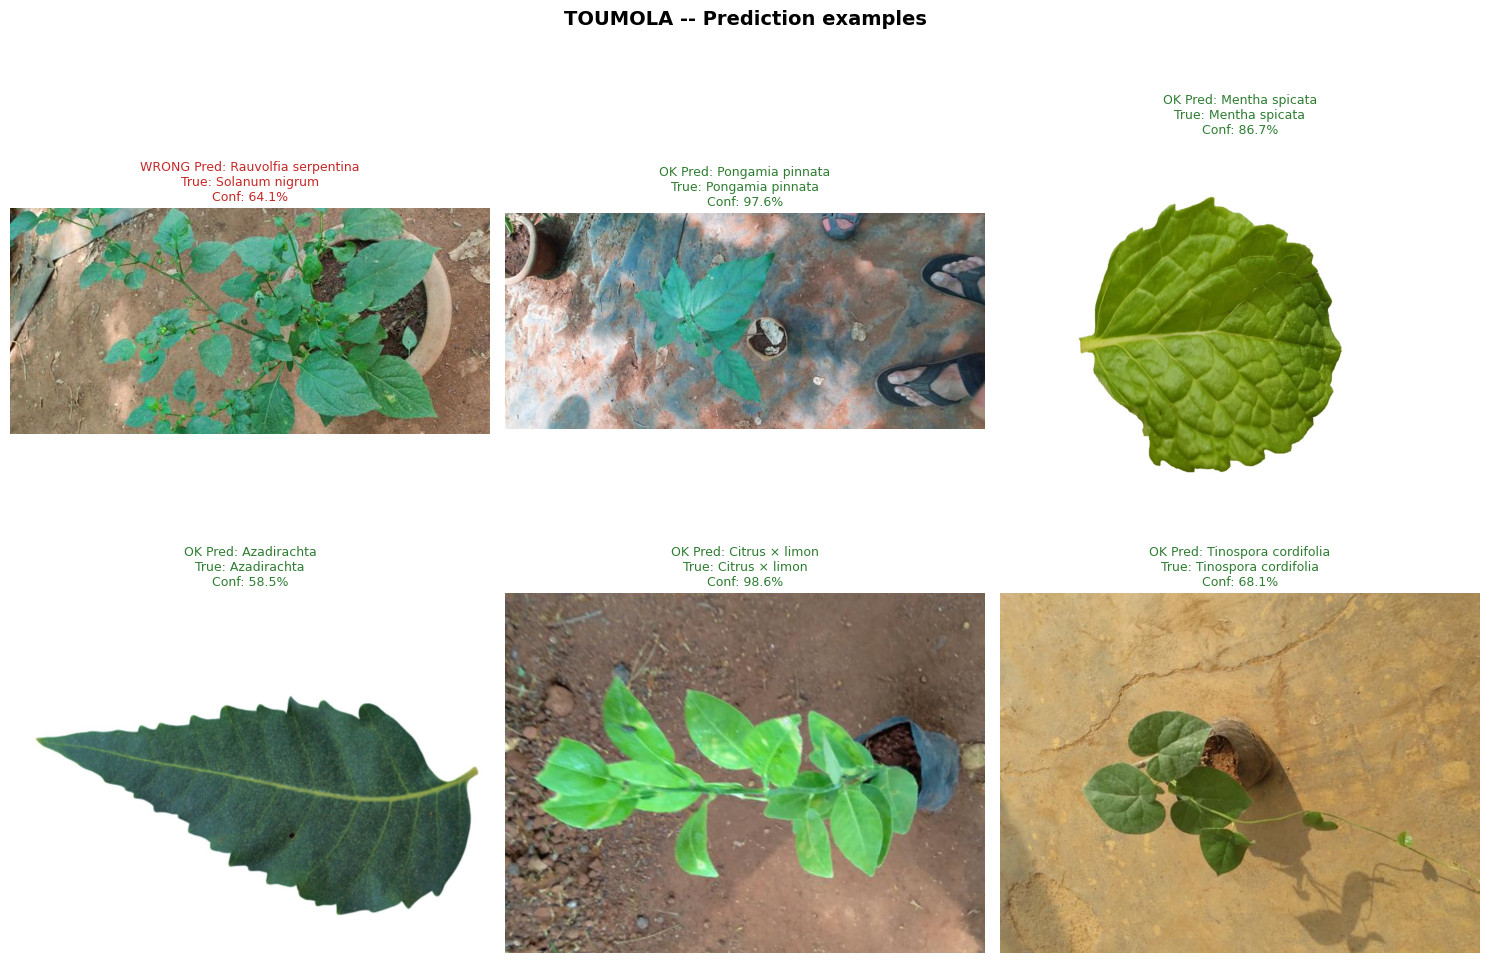


Sample complete record:


  IDENTIFIED PLANT RECORD

  Scientific name  : Rauvolfia serpentina
  Confiance        : 64.1%
  Family           : Apocynaceae
  Medicinal        : Oui

  Description:
    Arbuste originaire d'Inde et d'Asie du Sud-Est, source de ré
    serpine, l'un des premiers médicaments antihypertenseurs iso
    lés. Utilisé depuis des millénaires en médecine ayurvédique.

  Medicinal use:
     Antihypertenseur
     Anxiolytique
     Antipsychotique léger
     Sédatif
     Insomnie
     Morsures de serpent
     Fièvre
     Tachycardie
  Part used        : Racines | Écorce

  Alternatives:
     Solanum nigrum                      (24.7%)
     Pelargonium graveolens              (2.8%)




In [25]:
# Test on 6 random images from the test set
sample_indices = np.random.choice(len(df_test), min(6, len(df_test)), replace=False)
samples = df_test.iloc[sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (_, row) in enumerate(samples.iterrows()):
    if idx >= 6:
        break
    ax = axes[idx // 3][idx % 3]
    
    result = predict_plant(row["image_full_path"])
    pred   = result["prediction"]
    true_label = row["Nom_scientifique"]
    
    # Display the image
    try:
        img = Image.open(row["image_full_path"]).convert("RGB")
        ax.imshow(img)
    except:
        ax.set_facecolor('#f0f0f0')
    
    correct = pred["Nom_scientifique"] == true_label
    color = "#2E7D32" if correct else "#C62828"
    tick = "OK" if correct else "WRONG"
    
    ax.set_title(
        f"{tick} Pred: {pred['Nom_scientifique'][:22]}\n"
        f"True: {true_label[:22]}\n"
        f"Conf: {pred['Confiance']}",
        fontsize=9, color=color, pad=5
    )
    ax.axis('off')

plt.suptitle("TOUMOLA -- Prediction examples", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/prediction_examples.png", dpi=100, bbox_inches='tight')
plt.show()

# Affiche la fiche complète du premier exemple
print("\nSample complete record:")
result = predict_plant(samples.iloc[0]["image_full_path"])
print_record(result)


##  Step 15 — Saving and final summary

In [26]:
# Save the complete model with metadata
final_save = {
    "model_state_dict":  model.state_dict(),
    "num_classes":       NUM_CLASSES,
    "species_to_idx":    species_to_idx,
    "idx_to_species":    {str(k): v for k, v in idx_to_species.items()},
    "img_size":          IMG_SIZE,
    "best_val_acc":      best_val_acc,
    "model_name":        "efficientnet_b3",
}
final_model_path = f"{OUTPUT_DIR}/toumola_final.pth"
torch.save(final_save, final_model_path)

# Save plant info as JSON for the mobile app
plant_info_path = f"{OUTPUT_DIR}/plant_info.json"
with open(plant_info_path, "w", encoding="utf-8") as f:
    json.dump(plant_info, f, ensure_ascii=False, indent=2)

print("=" * 52)
print("         TOUMOLA -- TRAINING COMPLETE")
print("-" * 52)
print("  Model      : EfficientNetB3")
print(f"  Classes    : {NUM_CLASSES}")
print(f"  Best val   : {best_val_acc:.2%}")
print(f"  Test acc   : {test_acc:.2%}")
print("-" * 52)
print("  Generated files:")
print("    toumola_final.pth      (complete model)")
print("    labels.json            (class mapping)")
print("    plant_info.json        (plant records)")
print("    training_curves.png    (loss and accuracy curves)")
print("    confusion_matrix.png   (confusion matrix)")
print("    classification_report.txt")
print("=" * 52)
print(f"\nAll files saved in: {OUTPUT_DIR}")
print("\nDownload toumola_final.pth and plant_info.json")
print("to integrate them into your mobile application.")


         TOUMOLA -- TRAINING COMPLETE
----------------------------------------------------
  Model      : EfficientNetB3
  Classes    : 55
  Best val   : 95.37%
  Test acc   : 94.47%
----------------------------------------------------
  Generated files:
    toumola_final.pth      (complete model)
    labels.json            (class mapping)
    plant_info.json        (plant records)
    training_curves.png    (loss and accuracy curves)
    confusion_matrix.png   (confusion matrix)
    classification_report.txt

All files saved in: /kaggle/working/toumola_model

Download toumola_final.pth and plant_info.json
to integrate them into your mobile application.
